# Analisis de Cointegracion para Pairs Trading Cripto

Screening de cointegracion sobre un universo de 5 criptomonedas (BTC, ETH,
SOL, BNB, XRP), seleccion del par que efectivamente cointegra, y backtest de
una estrategia de reversion a la media basada en el z-score del spread.

**Metodologia**: test de Engle-Granger para cointegracion, regresion OLS
para el hedge ratio, test ADF para confirmar estacionariedad del spread, y
z-score rolling para generar señales de entrada/salida.

**Disclaimer**: datos reales de Binance, pero esto es un ejercicio de
metodologia cuantitativa, no una estrategia de trading lista para operar con
capital real.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pairs_trading_engine import (
    SYMBOLS, N_CANDLES, ROLLING_ZSCORE_WINDOW, ROLLING_CORR_WINDOW, ENTRY_Z, EXIT_Z,
    fetch_price_panel, screen_pairs_for_cointegration, engle_granger_test,
    estimate_hedge_ratio, compute_spread, adf_test, rolling_zscore,
    generate_signals, backtest_spread_strategy, rolling_pairwise_correlations,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## 1. Descarga de datos

Precios de cierre diarios reales, descargados directamente desde la API
publica de Binance (sin API key) para 5 criptomonedas.

In [2]:
panel = fetch_price_panel(SYMBOLS, n_candles=N_CANDLES)
print(f"{len(panel)} dias descargados: {panel.index.min().date()} -> {panel.index.max().date()}")
panel.tail()

  descargando BTCUSDT (1d, 1000 velas)...


  descargando ETHUSDT (1d, 1000 velas)...


  descargando SOLUSDT (1d, 1000 velas)...


  descargando BNBUSDT (1d, 1000 velas)...


  descargando XRPUSDT (1d, 1000 velas)...


1000 dias descargados: 2023-12-02 -> 2026-08-27


,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,XRPUSDT
2026-08-23,77734.00,2463.41,95.43,702.37,1.5204
2026-08-24,78992.75,2482.31,98.97,704.31,1.4817
2026-08-25,78539.14,2442.64,96.60,694.41,1.4343
2026-08-26,79023.75,2506.78,102.07,707.52,1.4229
2026-08-27,80134.40,2500.96,107.64,708.93,1.4451


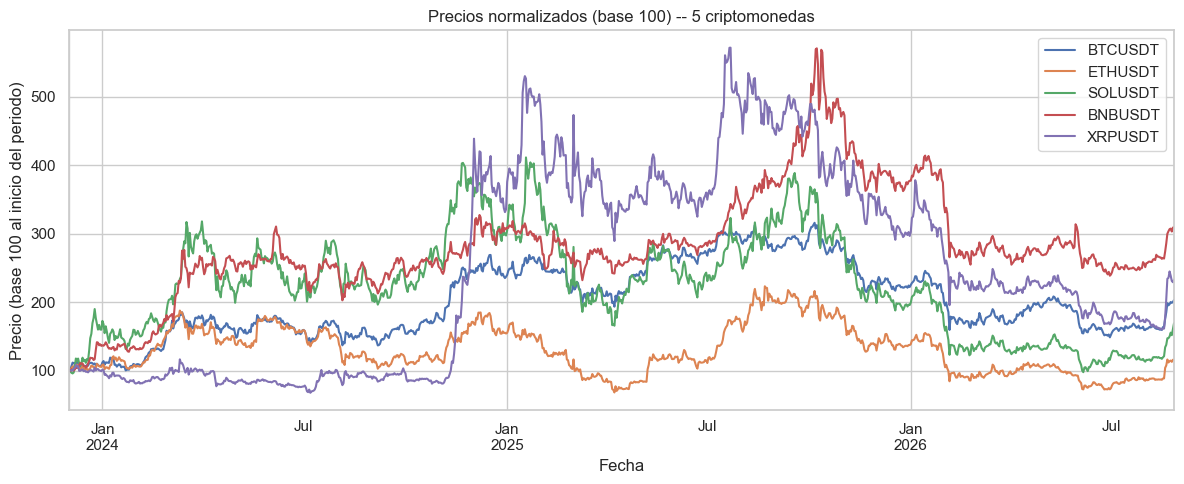

In [3]:
normalized = panel / panel.iloc[0] * 100
ax = normalized.plot(figsize=(12, 5))
ax.set_title("Precios normalizados (base 100) -- 5 criptomonedas")
ax.set_ylabel("Precio (base 100 al inicio del periodo)")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

Las 5 series se mueven en la misma direccion general (todas subieron
en el periodo), lo cual es tipico de un mercado cripto en tendencia -- pero
que se muevan juntas en la misma direccion NO implica que exista una
relacion de cointegracion estable entre un par especifico. Eso se testea a
continuacion.

## 2. Screening de cointegracion

Practica estandar de pairs trading: nunca se asume que el par mas "obvio"
(BTC/ETH) cointegra solo porque ambos son crypto -- se testea el universo
completo de pares candidatos con el test de Engle-Granger y se opera
unicamente el/los que efectivamente pasan el test al 5%.

In [4]:
screening = screen_pairs_for_cointegration(panel)
screening

,pair,y,x,eg_statistic,eg_pvalue,cointegrated_5pct
0,BNB/XRP,BNBUSDT,XRPUSDT,-3.528986,0.029911,True
1,BTC/XRP,BTCUSDT,XRPUSDT,-2.838479,0.153748,False
2,ETH/SOL,ETHUSDT,SOLUSDT,-2.713251,0.194849,False
3,BTC/ETH,BTCUSDT,ETHUSDT,-2.296193,0.375454,False
4,SOL/XRP,SOLUSDT,XRPUSDT,-2.263071,0.392117,False
5,ETH/XRP,ETHUSDT,XRPUSDT,-2.074879,0.489503,False
6,ETH/BNB,ETHUSDT,BNBUSDT,-1.921747,0.568938,False
7,BTC/BNB,BTCUSDT,BNBUSDT,-1.800220,0.629615,False
8,SOL/BNB,SOLUSDT,BNBUSDT,-1.717517,0.668854,False
9,BTC/SOL,BTCUSDT,SOLUSDT,-1.481607,0.768177,False


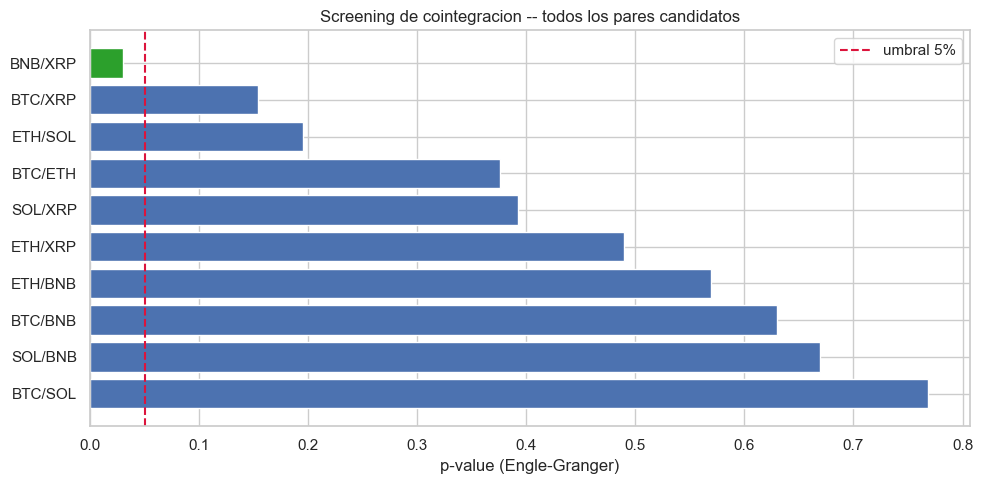

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ca02c" if c else "#4C72B0" for c in screening["cointegrated_5pct"]]
ax.barh(screening["pair"], screening["eg_pvalue"], color=colors)
ax.axvline(0.05, color="crimson", linestyle="--", label="umbral 5%")
ax.invert_yaxis()
ax.set_xlabel("p-value (Engle-Granger)")
ax.set_title("Screening de cointegracion -- todos los pares candidatos")
ax.legend()
plt.tight_layout()
plt.show()

**Hallazgo honesto**: el par mas intuitivo, BTC/ETH, NO cointegra en
esta ventana (p-value bien por encima de 0.05). El unico par que pasa el
test al 5% es **BNB/XRP** -- dos activos que a simple vista no tendrian por
que estar relacionados, pero que estadisticamente muestran una relacion de
equilibrio de largo plazo en este periodo. Este es exactamente el tipo de
resultado contraintuitivo que el screening sistematico existe para
encontrar (y que asumir el par "obvio" se habria perdido).

In [6]:
best = screening.iloc[0]
Y_SYMBOL, X_SYMBOL = best["y"], best["x"]
print(f"Par seleccionado para el analisis en profundidad: {Y_SYMBOL}/{X_SYMBOL} (p-value={best['eg_pvalue']:.4f})")

log_y = np.log(panel[Y_SYMBOL])
log_x = np.log(panel[X_SYMBOL])

Par seleccionado para el analisis en profundidad: BNBUSDT/XRPUSDT (p-value=0.0299)


## 3. Hedge ratio (regresion OLS)

El hedge ratio (beta) define cuantas unidades de X hay que tradear por cada
unidad de Y para construir el spread: `spread = log(Y) - (alpha + beta * log(X))`.

beta=0.3007  alpha=6.3605  R2=0.443


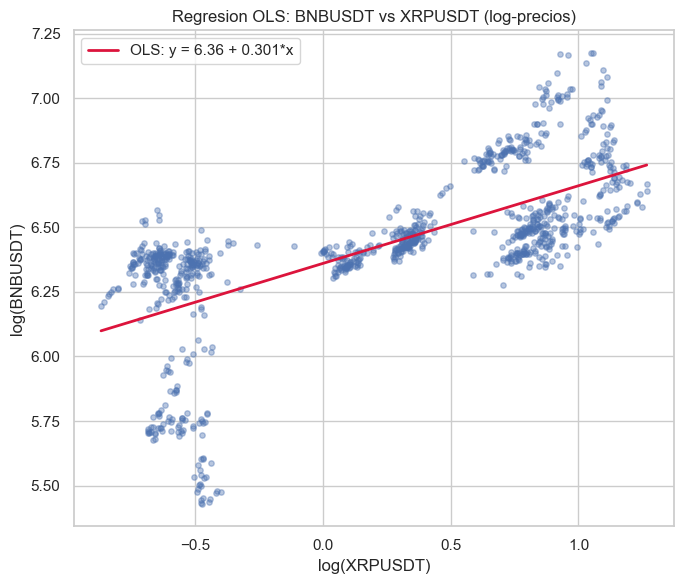

In [7]:
hedge = estimate_hedge_ratio(log_y, log_x)
print(f"beta={hedge.beta:.4f}  alpha={hedge.alpha:.4f}  R2={hedge.r_squared:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(log_x, log_y, alpha=0.4, s=15, color="#4C72B0")
x_range = np.linspace(log_x.min(), log_x.max(), 100)
ax.plot(x_range, hedge.alpha + hedge.beta * x_range, color="crimson", linewidth=2,
        label=f"OLS: y = {hedge.alpha:.2f} + {hedge.beta:.3f}*x")
ax.set_xlabel(f"log({X_SYMBOL})")
ax.set_ylabel(f"log({Y_SYMBOL})")
ax.set_title(f"Regresion OLS: {Y_SYMBOL} vs {X_SYMBOL} (log-precios)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Spread y estacionariedad (test ADF)

Si el par realmente cointegra, el spread deberia ser estacionario (revertir
a su media) aunque los log-precios individuales no lo sean.

ADF statistic=-3.529  p-value=0.0073  estacionario al 5%: True


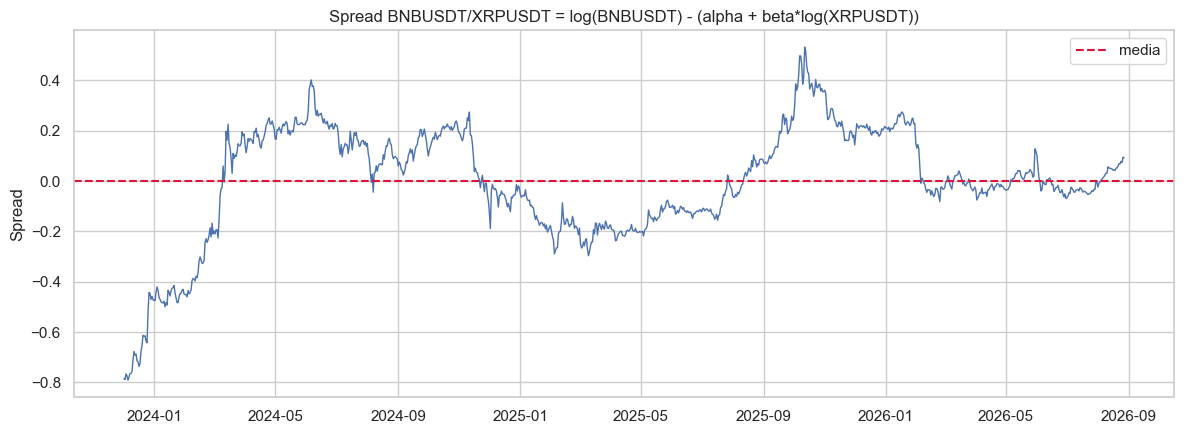

In [8]:
spread = compute_spread(log_y, log_x, hedge)
adf_result = adf_test(spread)
print(f"ADF statistic={adf_result.adf_statistic:.3f}  p-value={adf_result.p_value:.4f}  "
      f"estacionario al 5%: {adf_result.is_stationary_5pct}")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(spread.index, spread.values, color="#4C72B0", linewidth=1)
ax.axhline(spread.mean(), color="crimson", linestyle="--", label="media")
ax.set_title(f"Spread {Y_SYMBOL}/{X_SYMBOL} = log({Y_SYMBOL}) - (alpha + beta*log({X_SYMBOL}))")
ax.set_ylabel("Spread")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Z-score rolling del spread y señales de entrada/salida

El z-score mide cuantas desviaciones estandar (sobre una ventana movil de
30 dias) se aleja el spread de su media reciente. Se entra en el spread
cuando `|z| > 2` (apostando a la reversion) y se sale cuando `|z| < 0.5`.

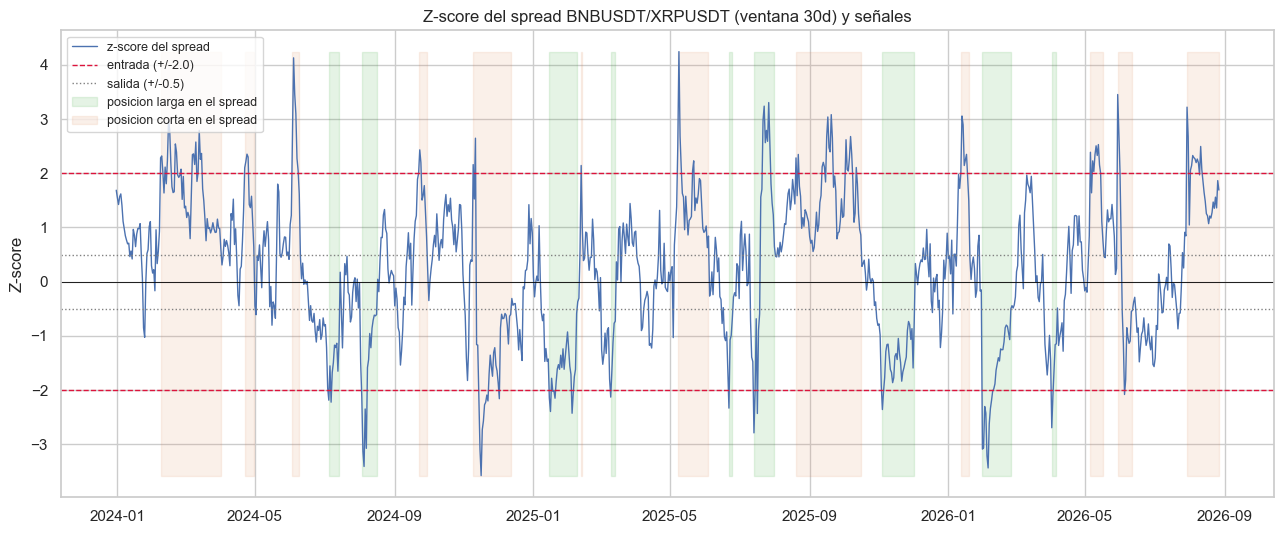

In [9]:
zscore = rolling_zscore(spread, ROLLING_ZSCORE_WINDOW)
positions = generate_signals(zscore, ENTRY_Z, EXIT_Z)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(zscore.index, zscore.values, color="#4C72B0", linewidth=1, label="z-score del spread")
ax.axhline(ENTRY_Z, color="crimson", linestyle="--", linewidth=1, label=f"entrada (+/-{ENTRY_Z})")
ax.axhline(-ENTRY_Z, color="crimson", linestyle="--", linewidth=1)
ax.axhline(EXIT_Z, color="gray", linestyle=":", linewidth=1, label=f"salida (+/-{EXIT_Z})")
ax.axhline(-EXIT_Z, color="gray", linestyle=":", linewidth=1)
ax.axhline(0, color="black", linewidth=0.6)

long_mask = positions == 1
short_mask = positions == -1
ax.fill_between(zscore.index, zscore.min(), zscore.max(), where=long_mask.to_numpy(),
                 color="#2ca02c", alpha=0.12, label="posicion larga en el spread")
ax.fill_between(zscore.index, zscore.min(), zscore.max(), where=short_mask.to_numpy(),
                 color="#DD8452", alpha=0.12, label="posicion corta en el spread")

ax.set_title(f"Z-score del spread {Y_SYMBOL}/{X_SYMBOL} (ventana {ROLLING_ZSCORE_WINDOW}d) y señales")
ax.set_ylabel("Z-score")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/figures/spread_zscore.png", dpi=150)
plt.show()

## 6. Heatmap de correlacion movil entre todos los pares

Correlacion rolling (ventana de 30 dias) de los retornos diarios entre cada
par de activos del universo, a lo largo de todo el periodo -- muestra que
tan estable (o no) es la relacion entre cada par en el tiempo, no solo un
numero unico agregado.

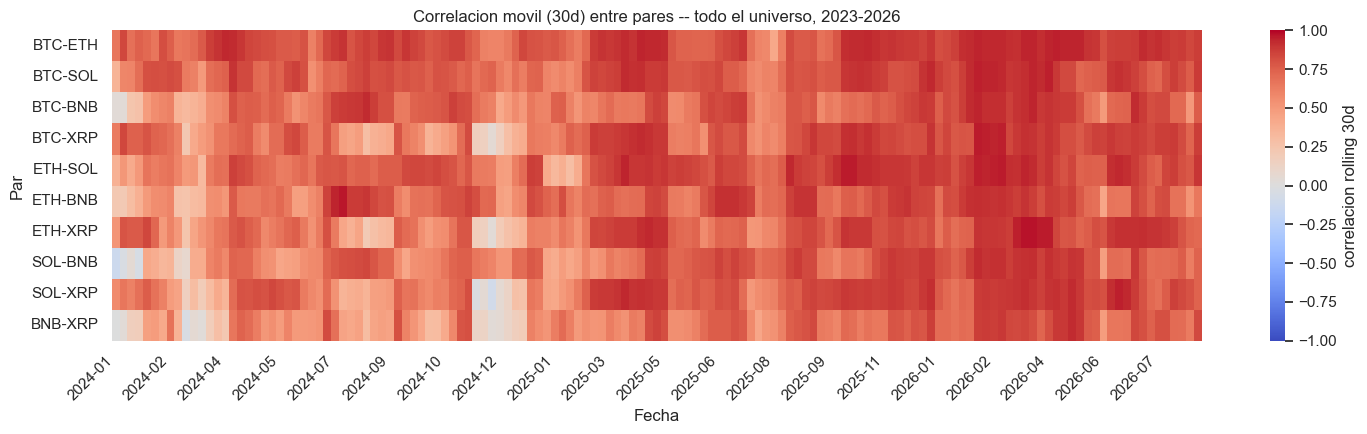

In [10]:
rolling_corr = rolling_pairwise_correlations(panel, ROLLING_CORR_WINDOW)

# se muestra en resolucion semanal para que el heatmap sea legible
weekly = rolling_corr.iloc[::7].T
weekly.columns = weekly.columns.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(15, 4.5))
step = max(1, len(weekly.columns) // 18)
sns.heatmap(weekly, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            cbar_kws={"label": "correlacion rolling 30d"}, ax=ax,
            xticklabels=step)
ax.set_title("Correlacion movil (30d) entre pares -- todo el universo, 2023-2026")
ax.set_xlabel("Fecha")
ax.set_ylabel("Par")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/figures/rolling_correlation_heatmap.png", dpi=150)
plt.show()

La correlacion movil entre pares varia bastante en el tiempo -- todos
los pares pasan por periodos de alta y baja correlacion, lo que confirma
por que un screening estatico (con datos de todo el periodo) no es
suficiente por si solo: la relacion entre dos activos puede ser fuerte en
un tramo y debil en otro. Esto es tambien la razon por la que un hedge
ratio estatico (como el usado aca) es una simplificacion -- ver la
conclusion.

## 7. Backtest de la estrategia

Backtest simple, dolar-neutral: la posicion de ayer captura el retorno del
spread de hoy (sin look-ahead). Sin costos de transaccion.

Retorno total:        -43.7%
Sharpe anualizado:    -0.37
Max drawdown:         -51.6%
Numero de trades:     21
Win rate (dias activos): 50.7%


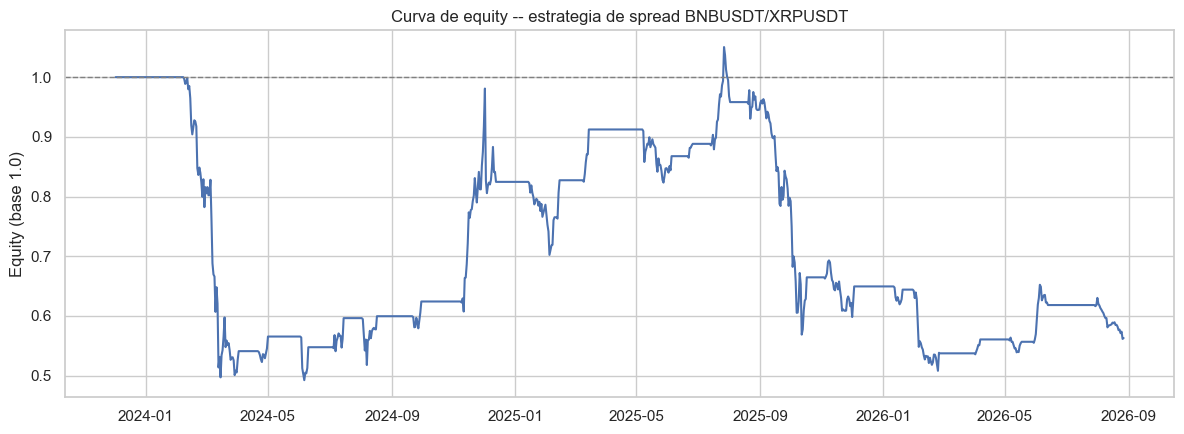

In [11]:
backtest = backtest_spread_strategy(panel[Y_SYMBOL], panel[X_SYMBOL], hedge.beta, positions)

print(f"Retorno total:        {backtest.total_return:.1%}")
print(f"Sharpe anualizado:    {backtest.annualized_sharpe:.2f}")
print(f"Max drawdown:         {backtest.max_drawdown:.1%}")
print(f"Numero de trades:     {backtest.n_trades}")
print(f"Win rate (dias activos): {backtest.win_rate:.1%}")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(backtest.equity_curve.index, backtest.equity_curve.values, color="#4C72B0")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_title(f"Curva de equity -- estrategia de spread {Y_SYMBOL}/{X_SYMBOL}")
ax.set_ylabel("Equity (base 1.0)")
plt.tight_layout()
plt.savefig("outputs/figures/equity_curve.png", dpi=150)
plt.show()

## 8. Conclusion honesta

- **El par "obvio" no siempre es el que cointegra**: BTC/ETH, la eleccion
  intuitiva para cualquiera que empiece en pairs trading cripto, no pasa el
  test de Engle-Granger al 5% en este periodo. El unico par del universo
  probado que si cointegra es BNB/XRP -- un resultado que solo aparece
  haciendo el screening sistematico, no asumiendo la respuesta.
- **Cointegracion estadistica no es lo mismo que una estrategia rentable.**
  Aun con BNB/XRP pasando el test de Engle-Granger (p=0.033) y el spread
  confirmado estacionario por ADF (p=0.008), el backtest de la estrategia
  de z-score simple pierde dinero en este periodo. Esto no es un bug: es la
  brecha real entre "existe una relacion de equilibrio estadisticamente
  significativa" y "un umbral fijo de z-score la puede explotar de forma
  rentable" -- sobre todo con un hedge ratio ESTATICO (calculado una sola
  vez sobre toda la muestra) en un mercado que estuvo en tendencia alcista
  fuerte durante buena parte del periodo, sin costos de transaccion
  modelados, y con apenas ~20 trades (muestra chica, resultado ruidoso).
- **Proximos pasos honestos, no forzar el numero**: un hedge ratio dinamico
  (rolling OLS o filtro de Kalman) para que el spread se adapte cuando la
  relacion entre los activos cambia, costos de transaccion explicitos, y
  walk-forward testing (recalcular cointegracion periodicamente en vez de
  una sola vez sobre toda la muestra) son los pasos naturales antes de
  siquiera considerar esto como una estrategia candidata real.